In [3]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 100)

In [4]:
dataset = pd.read_csv('data.csv', encoding="ISO-8859-1")


# Data Introduction

In [5]:
dataset.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [7]:
print(f"Dataset rows: {dataset.shape[0]}")
print(f"Dataset columns: {dataset.shape[1]}")

Dataset rows: 180519
Dataset columns: 53


# Preprocessing

In [8]:
modeling_columns = ['Type',
                  'Days for shipping (real)',
                  'Days for shipment (scheduled)',
                  'Benefit per order',
                  'Sales per customer',
                  'Late_delivery_risk',
                  'order date (DateOrders)',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Product Price',
                  'Order Item Profit Ratio',
                  'Order Item Quantity',
                  'Sales',
                  'Order Item Total',
                  'Order Profit Per Order',
                  'Product Price',
                  'shipping date (DateOrders)',
                  'Shipping Mode']

In [9]:
def drop_columns(dataset, columns_to_drop):
    dataset = dataset.drop(columns=columns_to_drop)
    print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(dataset.columns)}")
    return dataset

In [10]:
columns_to_drop = [col for col in dataset.columns if col not in modeling_columns]

dataset = drop_columns(dataset, columns_to_drop)

35 columns dropped successfully. Number of columns remaining: 18


In [11]:
dataset.head(10)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,327.75,1/15/2018 11:24,Standard Class
5,TRANSFER,6,4,18.580000,294.980011,0,1/13/2018 11:03,32.779999,0.10,327.75,0.06,1,327.75,294.980011,18.580000,327.75,1/19/2018 11:03,Standard Class
6,DEBIT,2,1,95.180000,288.420013,1,1/13/2018 10:42,39.330002,0.12,327.75,0.33,1,327.75,288.420013,95.180000,327.75,1/15/2018 10:42,First Class
7,TRANSFER,2,1,68.430000,285.140015,1,1/13/2018 10:21,42.610001,0.13,327.75,0.24,1,327.75,285.140015,68.430000,327.75,1/15/2018 10:21,First Class
8,CASH,3,2,133.720001,278.589996,1,1/13/2018 10:00,49.160000,0.15,327.75,0.48,1,327.75,278.589996,133.720001,327.75,1/16/2018 10:00,Second Class
9,CASH,2,1,132.149994,275.309998,1,1/13/2018 9:39,52.439999,0.16,327.75,0.48,1,327.75,275.309998,132.149994,327.75,1/15/2018 9:39,First Class


In [12]:
# check null values
dataset.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
order date (DateOrders)          0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales                            0
Order Item Total                 0
Order Profit Per Order           0
Product Price                    0
shipping date (DateOrders)       0
Shipping Mode                    0
dtype: int64

In [13]:
dataset.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

In [14]:
dataset['Late_delivery_risk_name'] = dataset['Late_delivery_risk'].map({
    0: 'Late',
    1: 'Not late',
})

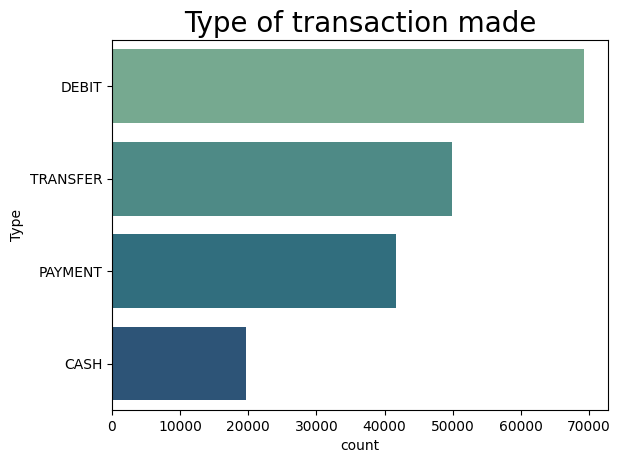

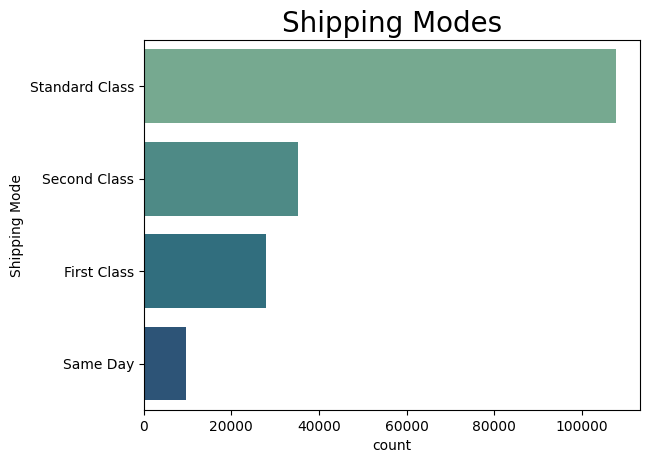

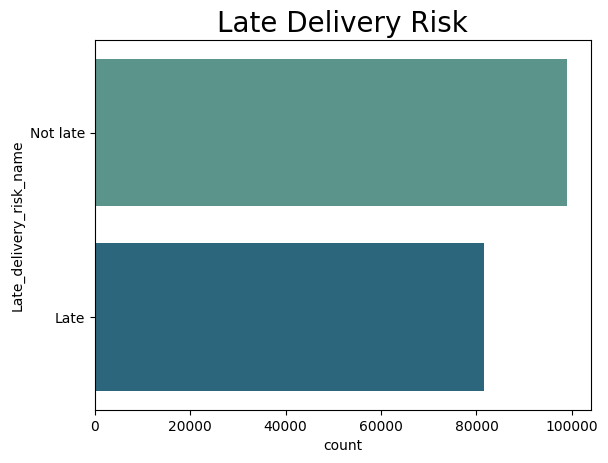

In [15]:
def bar_chart(category, title):
    sns.countplot(data = dataset, y = dataset[category],order= dataset[category].value_counts().index, palette='crest')
    plt.title(title, size = 20)
    plt.show()

bar_chart("Type","Type of transaction made")
bar_chart("Shipping Mode","Shipping Modes")
bar_chart("Late_delivery_risk_name","Late Delivery Risk")

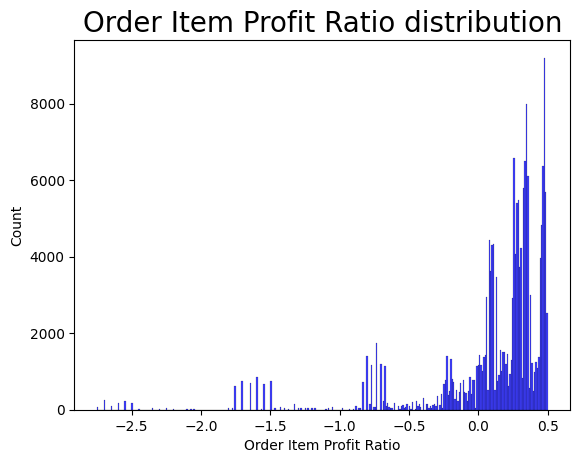

In [16]:
def quant_count(num_var, title):
    sns.histplot(dataset[num_var] ,kde=False,color = "Blue")
    plt.title(title, size = 20)
    plt.show()

quant_count("Order Item Profit Ratio", "Order Item Profit Ratio distribution")

In [17]:
dataset.drop('Late_delivery_risk_name', axis=1)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,1/31/2018 22:56,13.110000,0.04,327.750000,0.29,1,327.750000,314.640015,91.250000,327.750000,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,1/13/2018 12:27,16.389999,0.05,327.750000,-0.80,1,327.750000,311.359985,-249.089996,327.750000,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,1/13/2018 12:06,18.030001,0.06,327.750000,-0.80,1,327.750000,309.720001,-247.779999,327.750000,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,1/13/2018 11:45,22.940001,0.07,327.750000,0.08,1,327.750000,304.809998,22.860001,327.750000,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,1/13/2018 11:24,29.500000,0.09,327.750000,0.45,1,327.750000,298.250000,134.210007,327.750000,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,1/16/2016 3:40,0.000000,0.00,399.980011,0.10,1,399.980011,399.980011,40.000000,399.980011,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,1/16/2016 1:34,4.000000,0.01,399.980011,-1.55,1,399.980011,395.980011,-613.770019,399.980011,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,1/15/2016 21:00,8.000000,0.02,399.980011,0.36,1,399.980011,391.980011,141.110001,399.980011,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,1/15/2016 20:18,12.000000,0.03,399.980011,0.48,1,399.980011,387.980011,186.229996,399.980011,1/18/2016 20:18,Standard Class


# Feature Engineering

## Date Parsing

In [18]:
dataset['Order Year'] = pd.DatetimeIndex(dataset['order date (DateOrders)']).year
dataset['Order Month'] = pd.DatetimeIndex(dataset['order date (DateOrders)']).month
dataset['Order Day'] = pd.DatetimeIndex(dataset['order date (DateOrders)']).day
dataset['Order Day of Week'] = pd.DatetimeIndex(dataset['order date (DateOrders)']).dayofweek
dataset['Order Hour'] = pd.DatetimeIndex(dataset['order date (DateOrders)']).hour
dataset['Shipping Year'] = pd.DatetimeIndex(dataset['shipping date (DateOrders)']).year
dataset['Shipping Month'] = pd.DatetimeIndex(dataset['shipping date (DateOrders)']).month
dataset['Shipping Day'] = pd.DatetimeIndex(dataset['shipping date (DateOrders)']).day
dataset['Shipping Day of Week'] = pd.DatetimeIndex(dataset['shipping date (DateOrders)']).dayofweek
dataset['Shipping Hour'] = pd.DatetimeIndex(dataset['shipping date (DateOrders)']).hour

dataset.drop(columns = ['order date (DateOrders)', 'shipping date (DateOrders)'], inplace = True)

In [19]:
dataset.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,Shipping Mode,Late_delivery_risk_name,Order Year,Order Month,Order Day,Order Day of Week,Order Hour,Shipping Year,Shipping Month,Shipping Day,Shipping Day of Week,Shipping Hour
0,DEBIT,3,4,91.250000,314.640015,0,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,327.75,Standard Class,Late,2018,1,31,2,22,2018,2,3,5,22
1,TRANSFER,5,4,-249.089996,311.359985,1,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,327.75,Standard Class,Not late,2018,1,13,5,12,2018,1,18,3,12
2,CASH,4,4,-247.779999,309.720001,0,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,327.75,Standard Class,Late,2018,1,13,5,12,2018,1,17,2,12
3,DEBIT,3,4,22.860001,304.809998,0,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,327.75,Standard Class,Late,2018,1,13,5,11,2018,1,16,1,11
4,PAYMENT,2,4,134.210007,298.250000,0,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,327.75,Standard Class,Late,2018,1,13,5,11,2018,1,15,0,11


In [20]:
dataset['Shipping Day of Week Name'] = dataset['Shipping Day of Week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})

dataset['Order Day of Week Name'] = dataset['Order Day of Week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})

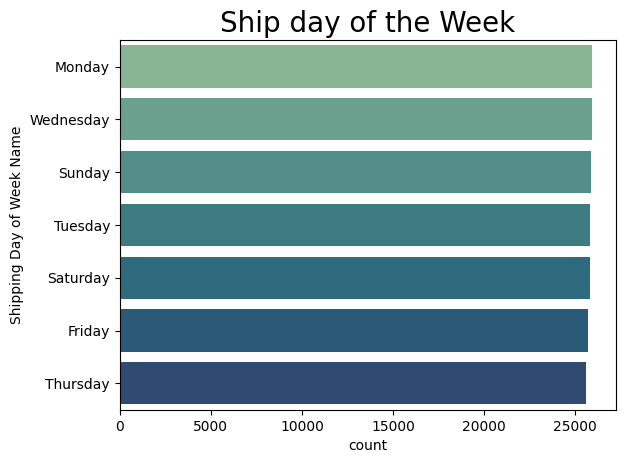

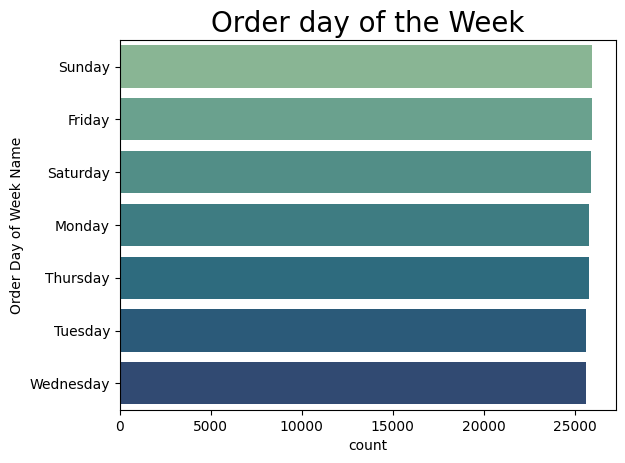

In [21]:
bar_chart("Shipping Day of Week Name","Ship day of the Week")
bar_chart("Order Day of Week Name","Order day of the Week")

In [22]:
dataset.drop(['Shipping Day of Week Name', 'Order Day of Week Name',
           'Late_delivery_risk_name'
           ], axis=1, inplace=True)

## Categorical Encoding

In [23]:
dataset = pd.get_dummies(dataset)
print(dataset.shape)
dataset.head()

(180519, 32)


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,Order Year,Order Month,Order Day,Order Day of Week,Order Hour,Shipping Year,Shipping Month,Shipping Day,Shipping Day of Week,Shipping Hour,Type_CASH,Type_DEBIT,Type_PAYMENT,Type_TRANSFER,Shipping Mode_First Class,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,3,4,91.250000,314.640015,0,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,327.75,2018,1,31,2,22,2018,2,3,5,22,False,True,False,False,False,False,False,True
1,5,4,-249.089996,311.359985,1,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,327.75,2018,1,13,5,12,2018,1,18,3,12,False,False,False,True,False,False,False,True
2,4,4,-247.779999,309.720001,0,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,327.75,2018,1,13,5,12,2018,1,17,2,12,True,False,False,False,False,False,False,True
3,3,4,22.860001,304.809998,0,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,327.75,2018,1,13,5,11,2018,1,16,1,11,False,True,False,False,False,False,False,True
4,2,4,134.210007,298.250000,0,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,327.75,2018,1,13,5,11,2018,1,15,0,11,False,False,True,False,False,False,False,True


In [24]:
dataset = dataset.astype({col: int for col in dataset.select_dtypes(include=['bool']).columns})
dataset.head()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,Order Year,Order Month,Order Day,Order Day of Week,Order Hour,Shipping Year,Shipping Month,Shipping Day,Shipping Day of Week,Shipping Hour,Type_CASH,Type_DEBIT,Type_PAYMENT,Type_TRANSFER,Shipping Mode_First Class,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,3,4,91.250000,314.640015,0,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,327.75,2018,1,31,2,22,2018,2,3,5,22,0,1,0,0,0,0,0,1
1,5,4,-249.089996,311.359985,1,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,327.75,2018,1,13,5,12,2018,1,18,3,12,0,0,0,1,0,0,0,1
2,4,4,-247.779999,309.720001,0,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,327.75,2018,1,13,5,12,2018,1,17,2,12,1,0,0,0,0,0,0,1
3,3,4,22.860001,304.809998,0,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,327.75,2018,1,13,5,11,2018,1,16,1,11,0,1,0,0,0,0,0,1
4,2,4,134.210007,298.250000,0,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,327.75,2018,1,13,5,11,2018,1,15,0,11,0,0,1,0,0,0,0,1


## Handle Outliers

In [25]:
float_cols = dataset.select_dtypes(include=['float']).columns

z_scores = np.abs(stats.zscore(dataset[float_cols]))

threshold = 3.0

outlier_counts = {}

for col in float_cols:
    col_z_scores = np.abs(stats.zscore(dataset[col]))  # Compute Z-scores for the column
    outlier_counts[col] = (col_z_scores > threshold).sum()
    median_value = dataset[col].median()
    dataset.loc[col_z_scores > threshold, col] = median_value

print(outlier_counts)

{'Benefit per order': np.int64(3608), 'Sales per customer': np.int64(477), 'Order Item Discount': np.int64(2106), 'Order Item Discount Rate': np.int64(0), 'Order Item Product Price': np.int64(488), 'Order Item Profit Ratio': np.int64(6013), 'Sales': np.int64(467), 'Order Item Total': np.int64(477), 'Order Profit Per Order': np.int64(3608), 'Product Price': np.int64(488)}


## Normalization

In [26]:
dataset[float_cols] = (dataset[float_cols] - dataset[float_cols].min()) / (dataset[float_cols].max() - dataset[float_cols].min())
dataset.head(10)

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price,Order Year,Order Month,Order Day,Order Day of Week,Order Hour,Shipping Year,Shipping Month,Shipping Day,Shipping Day of Week,Shipping Hour,Type_CASH,Type_DEBIT,Type_PAYMENT,Type_TRANSFER,Shipping Mode_First Class,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,3,4,0.614174,0.576808,0,0.153351,0.16,0.608048,0.880000,1,0.538576,0.576808,0.614174,0.608048,2018,1,31,2,22,2018,2,3,5,22,0,1,0,0,0,0,0,1
1,5,4,0.067610,0.570648,1,0.191718,0.20,0.608048,0.257143,1,0.538576,0.570648,0.067610,0.608048,2018,1,13,5,12,2018,1,18,3,12,0,0,0,1,0,0,0,1
2,4,4,0.069714,0.567568,0,0.210902,0.24,0.608048,0.257143,1,0.538576,0.567568,0.069714,0.608048,2018,1,13,5,12,2018,1,17,2,12,1,0,0,0,0,0,0,1
3,3,4,0.504344,0.558347,0,0.268335,0.28,0.608048,0.760000,1,0.538576,0.558347,0.504344,0.608048,2018,1,13,5,11,2018,1,16,1,11,0,1,0,0,0,0,0,1
4,2,4,0.683165,0.546028,0,0.345070,0.36,0.608048,0.971429,1,0.538576,0.546028,0.683165,0.608048,2018,1,13,5,11,2018,1,15,0,11,0,0,1,0,0,0,0,1
5,6,4,0.497471,0.539887,0,0.383437,0.40,0.608048,0.748571,1,0.538576,0.539887,0.497471,0.608048,2018,1,13,5,11,2018,1,19,4,11,0,0,0,1,0,0,0,1
6,2,1,0.620485,0.527568,1,0.460054,0.48,0.608048,0.902857,1,0.538576,0.527568,0.620485,0.608048,2018,1,13,5,10,2018,1,15,0,10,0,1,0,0,1,0,0,0
7,2,1,0.577527,0.521408,1,0.498421,0.52,0.608048,0.851429,1,0.538576,0.521408,0.577527,0.608048,2018,1,13,5,10,2018,1,15,0,10,0,0,0,1,1,0,0,0
8,3,2,0.682378,0.509108,1,0.575038,0.60,0.608048,0.988571,1,0.538576,0.509108,0.682378,0.608048,2018,1,13,5,10,2018,1,16,1,10,1,0,0,0,0,0,1,0
9,2,1,0.679857,0.502948,1,0.613405,0.64,0.608048,0.988571,1,0.538576,0.502948,0.679857,0.608048,2018,1,13,5,9,2018,1,15,0,9,1,0,0,0,1,0,0,0


# Model Training and Evaluation

In [27]:
X = dataset.drop('Late_delivery_risk', axis=1)
y = dataset['Late_delivery_risk']

In [28]:
X = dataset.drop('Late_delivery_risk', axis=1)
y = dataset['Late_delivery_risk']
X.to_csv('X.csv', index=False)
y.to_csv('y.csv', index=False)

In [60]:
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    max_depth=None,         # max depth of each tree
    random_state=42
)
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,       # number of boosting rounds
    learning_rate=0.1,      # step size shrinkage
    max_depth=None,            # max depth of each tree
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
# 4. Define stacking ensemble
# Stacking uses the predictions of base models as input for a final meta-model
stack_model = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],  # base models
    final_estimator=LogisticRegression(),             # meta-model
    cv=5,                                            # cross-validation for stacking
    n_jobs=-1                                        # parallelize training
)

# 5. Train stacking model
stack_model.fit(X_train, y_train)

# 6. Predict on test set
preds = stack_model.predict(X_test)
proba = stack_model.predict_proba(X_test)

# 7. Evaluate performance
accuracy = accuracy_score(y_test, preds)
ll = log_loss(y_test, proba)

print(f"Stacking Model Accuracy: {accuracy * 100:.2f}%")
print(f"Stacking Model LogLoss: {ll:.4f}")

# Optional: Detailed classification metrics per class
print(classification_report(y_test, preds))


Stacking Model Accuracy: 97.69%
Stacking Model LogLoss: 0.0621
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     16307
           1       0.96      0.99      0.98     19797

    accuracy                           0.98     36104
   macro avg       0.98      0.97      0.98     36104
weighted avg       0.98      0.98      0.98     36104



## Compute Log Loss from the Highest Performing Model

In [ ]:
from sklearn.metrics import log_loss

y_proba = stack_model.predict_proba(X_test)

# Compute log loss
loss = log_loss(y_test, y_proba)
print(f'Log Loss: {loss:.4f}')

Log Loss: 0.0640


In [ ]:
import joblib
filename = 'late_delivery_risk_model_2.pkl'

joblib.dump(stack_model, filename)

print(f"Model saved to {filename}")

Model saved to late_delivery_risk_model_2.pkl
